# Neural Network: Regression

The one-hidden-layer network from `breast-cancer-neural-network.ipynb`, adapted from classification to regression and applied to the [NASA Airfoil Self-Noise](https://archive.ics.uci.edu/ml/datasets/Airfoil+Self-Noise) dataset.

The data comes from wind tunnel tests of airfoil blade sections: 1,503 measurements with five inputs (frequency, angle of attack, chord length, free-stream velocity, and suction side displacement thickness), predicting the scaled sound pressure level in decibels.

Two changes turn the classifier into a regressor:

- **The output activation is removed.** `A2 = Z2`, a linear output, because the target is an unbounded real number rather than a probability.
- **Mean squared error replaces cross-entropy** as the cost.

The hidden layer, backpropagation and gradient descent are unchanged. Everything is written in numpy; scikit-learn supplies only the split, the scalers and the final error metrics.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
# for reproducibility
np.random.seed(777)

## 1. Loading and preprocessing the data

Split 70/15/15 with seed 777, then standard-scaled with scalers fit on the training split only and transposed to (features x examples) to match the network's orientation.

**The target is scaled as well as the features**, which matters more here than in the classification notebooks. Sound pressure levels average about 125 dB, and feeding a target that large into a network whose weights start near zero produces enormous initial errors and correspondingly enormous gradients. Standardizing the target keeps the optimization well conditioned. Predictions are inverse-transformed back to decibels before any error is reported, so the final numbers are in real physical units rather than standard deviations.


In [3]:
# Columns: Freq, Angle, Chord, Velocity, Suction, Sound Pressure (Target)
df = pd.read_csv('Airfoil.csv', header=None)

# Separate Features and Target
X_raw = df.iloc[:, :-1].values
y_raw = df.iloc[:, -1].values.reshape(-1, 1) # Reshape to (m, 1)

In [4]:
# Data Splitting: 70% Train, 15% Validation, 15% Test
# First split: 70% Train, 30% Temp
X_train_raw, X_temp, y_train_raw, y_temp = train_test_split(X_raw, y_raw, test_size=0.3, random_state=777)

# Second split: Split the 30% Temp into 50/50 (resulting in 15% Val, 15% Test)
X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split(X_temp, y_temp, test_size=0.5, random_state=777)

# Feature Scaling --> Standardization is crucial for Regression NN
scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(X_train_raw)
X_val_scaled = scaler_x.transform(X_val_raw)
X_test_scaled = scaler_x.transform(X_test_raw)

# Target Scaling
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train_raw)
y_val_scaled = scaler_y.transform(y_val_raw)
y_test_scaled = scaler_y.transform(y_test_raw)

# Reshape (features x examples). NN Convention: Rows = Features, Columns = Examples.
X_train = X_train_scaled.T
Y_train = y_train_scaled.T

X_val = X_val_scaled.T
Y_val = y_val_scaled.T

X_test = X_test_scaled.T
Y_test = y_test_scaled.T

print(f"Shapes -> X_train: {X_train.shape}, Y_train: {Y_train.shape}")

Shapes -> X_train: (5, 1052), Y_train: (1, 1052)


## 2. The network

A linear output layer and an MSE cost, with the hidden layer left as `tanh`.

The backward pass is worth pausing on, because it is byte-for-byte the same as in the classification notebooks. `dZ2 = A2 - Y` holds for a linear output with MSE exactly as it did for a sigmoid output with binary cross-entropy, and for a softmax output with categorical cross-entropy.

That is not a coincidence. Each of those three activation and cost pairings is chosen precisely so that the derivative of the activation and the derivative of the cost cancel, leaving the same simple difference. It is why one backpropagation implementation serves binary classification, multiclass classification and regression without modification.


In [5]:
def initialize_parameters(n_x, n_h, n_y):
    np.random.seed(777)
    W1 = np.random.randn(n_h, n_x) * 0.01
    b1 = np.zeros((n_h, 1))
    W2 = np.random.randn(n_y, n_h) * 0.01
    b2 = np.zeros((n_y, 1))
    
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}

def forward_propagation(X, parameters):
    W1, b1, W2, b2 = parameters["W1"], parameters["b1"], parameters["W2"], parameters["b2"]
    
    # Hidden Layer: Tanh is stable, ReLU is also good
    Z1 = np.dot(W1, X) + b1
    A1 = np.tanh(Z1) 
    
    # Output Layer: Linear for Regression
    Z2 = np.dot(W2, A1) + b2
    A2 = Z2 
    
    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
    return A2, cache

def compute_cost(A2, Y):
    m = Y.shape[1]
    
    # MSE Cost
    cost = (1 / (2 * m)) * np.sum(np.square(A2 - Y))
    return float(np.squeeze(cost))

def backprop(parameters, cache, X, Y):
    m = X.shape[1]
    W2 = parameters["W2"]
    A1 = cache["A1"]
    A2 = cache["A2"]
    
    # Gradients of Output Layer: for MSE plus Linear Output
    dZ2 = A2 - Y 
    dW2 = (1/m) * np.dot(dZ2, A1.T)
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)
    
    # Gradients of Hidden Layer: Tanh derivative: 1 - A1^2
    dZ1 = np.dot(W2.T, dZ2) * (1 - np.power(A1, 2))
    dW1 = (1/m) * np.dot(dZ1, X.T)
    db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)
    
    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

def update_parameters(parameters, grads, learning_rate):
    parameters["W1"] -= learning_rate * grads["dW1"]
    parameters["b1"] -= learning_rate * grads["db1"]
    parameters["W2"] -= learning_rate * grads["dW2"]
    parameters["b2"] -= learning_rate * grads["db2"]
    return parameters

In [6]:
def RegressionModel(X_train, Y_train, X_val, Y_val, n_h=20, num_iterations=10000, learning_rate=0.01, print_cost=True):
    n_x = X_train.shape[0]
    n_y = Y_train.shape[0] 
    
    parameters = initialize_parameters(n_x, n_h, n_y)
    costs = []
    
    for i in range(num_iterations):
        # Forward Prop
        A2, cache = forward_propagation(X_train, parameters)
        
        cost = compute_cost(A2, Y_train)
        
        grads = backprop(parameters, cache, X_train, Y_train)
        
        parameters = update_parameters(parameters, grads, learning_rate)
        
        if i % 1000 == 0:
            costs.append(cost)
            if print_cost:
                print(f"MSE Cost after iteration {i}: {cost}")
                
    return parameters, costs

## 3. Training

Trained with 25 hidden units at a learning rate of 0.05 for 15,000 iterations.

The starting cost is a free correctness check. With a standardized target the variance is 1, and with near-zero initial weights the network predicts approximately zero, so the cost $\frac{1}{2m}\sum(A^{[2]} - Y)^2$ should begin at roughly **0.5**. Anything far from that would point to a bug in the scaling or the cost before a single gradient step had been taken.

As in the multiclass notebook, a validation split is built above but is not used to tune anything; `X_val` and `Y_val` are passed to the model without being read.


MSE Cost after iteration 0: 0.49991714953313376
MSE Cost after iteration 1000: 0.23522318688837057


MSE Cost after iteration 2000: 0.2031954382261961
MSE Cost after iteration 3000: 0.19563883087038375


MSE Cost after iteration 4000: 0.18357199993519482
MSE Cost after iteration 5000: 0.17031978222950184


MSE Cost after iteration 6000: 0.1517450158289154
MSE Cost after iteration 7000: 0.13741958645948466


MSE Cost after iteration 8000: 0.12673257728930837
MSE Cost after iteration 9000: 0.11556102973311269


MSE Cost after iteration 10000: 0.1063366013489643
MSE Cost after iteration 11000: 0.1003201299595078


MSE Cost after iteration 12000: 0.09544905174565112
MSE Cost after iteration 13000: 0.09011185802068783


MSE Cost after iteration 14000: 0.08525912138672397


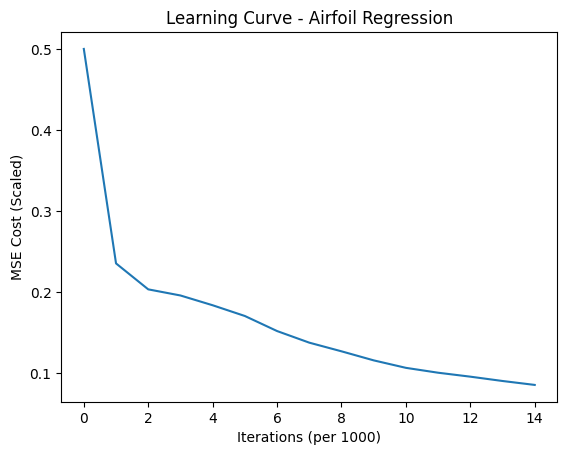

In [7]:
parameters, costs = RegressionModel(X_train, Y_train, X_val, Y_val, n_h=25, num_iterations=15000, learning_rate=0.05)

plt.plot(costs)
plt.ylabel('MSE Cost (Scaled)')
plt.xlabel('Iterations (per 1000)')
plt.title('Learning Curve - Airfoil Regression')
plt.show()

## 4. Evaluation on the test set

Predictions are inverse-transformed back to decibels before MSE and MAE are computed, so both are in the same units as the measurements. A predicted-versus-actual scatter against the diagonal shows where the model tracks the data and where it drifts.



=== Final Results on Test Set ===
Mean Squared Error (MSE): 6.7282
Mean Absolute Error (MAE): 2.0185


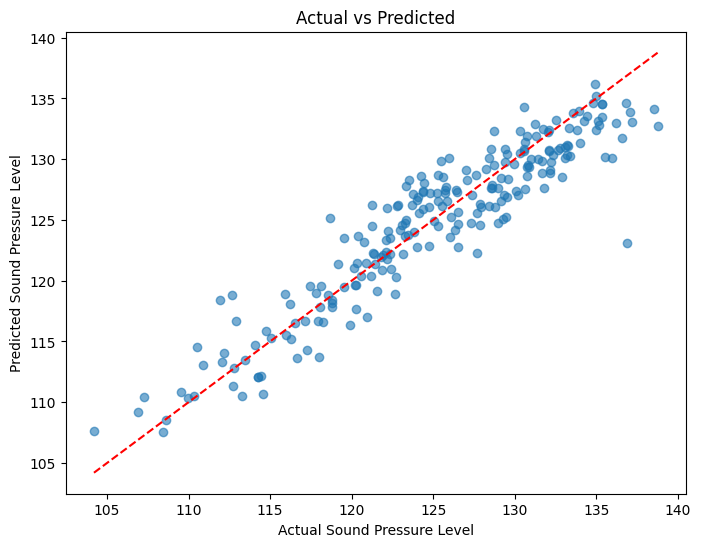

In [8]:
def predict(parameters, X):
    A2, _ = forward_propagation(X, parameters)
    return A2

# Predictions on Test Set (Scaled)
Y_pred_scaled = predict(parameters, X_test)

# Inverse Transform to get actual Sound Pressure Levels (Decibels)
Y_pred_actual = scaler_y.inverse_transform(Y_pred_scaled.T)
Y_test_actual = scaler_y.inverse_transform(Y_test.T)

mse = mean_squared_error(Y_test_actual, Y_pred_actual)
mae = mean_absolute_error(Y_test_actual, Y_pred_actual)

print("\n=== Final Results on Test Set ===")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

# Prediction vs Actual
plt.figure(figsize=(8, 6))
plt.scatter(Y_test_actual, Y_pred_actual, alpha=0.6)
plt.plot([Y_test_actual.min(), Y_test_actual.max()], [Y_test_actual.min(), Y_test_actual.max()], 'r--')
plt.xlabel('Actual Sound Pressure Level')
plt.ylabel('Predicted Sound Pressure Level')
plt.title('Actual vs Predicted')
plt.show()